In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv('/content/sample_data/Churn_Modelling.csv')

# Drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [15]:
# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Define features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

In [16]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.865


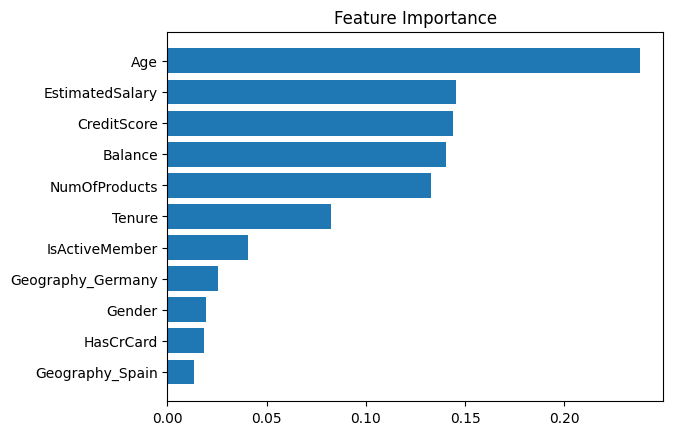

              Feature  Importance
2                 Age    0.238058
8     EstimatedSalary    0.145321
0         CreditScore    0.143814
4             Balance    0.140376
5       NumOfProducts    0.132759
3              Tenure    0.082558
7      IsActiveMember    0.040464
9   Geography_Germany    0.025593
1              Gender    0.019363
6           HasCrCard    0.018399
10    Geography_Spain    0.013294


In [17]:
# Feature Importance
importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

print(feat_imp)